<a href="https://colab.research.google.com/github/sirishamallavalli/Multi-Modal-Skin-Lesion-Classification/blob/main/Multi_Modal_Skin_Lesion_Classification2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Concatenate

In [ ]:
base_path = "/content/drive/MyDrive/pad-ufes-20"

metadata_path = os.path.join(base_path, "metadata.csv")

image_folders = [
    os.path.join(base_path, "imgs_part_1"),
    os.path.join(base_path, "imgs_part_2"),
    os.path.join(base_path, "imgs_part_3")
]

In [ ]:
import os

base_path = "/content/drive/MyDrive/pad-ufes-20"

print(os.listdir(base_path))

['metadata.csv', 'imgs_part_1.zip', 'imgs_part_2.zip', 'imgs_part_3.zip', 'metadata.gsheet']


In [ ]:
import os

base_path = "/content/drive/MyDrive/pad-ufes-20"

print(os.listdir(base_path))

['metadata.csv', 'imgs_part_1.zip', 'imgs_part_2.zip', 'imgs_part_3.zip', 'metadata.gsheet']


In [ ]:
!unzip -q "/content/drive/MyDrive/pad-ufes-20/imgs_part_1.zip" -d "/content/"

In [ ]:
!unzip -oq "/content/drive/MyDrive/pad-ufes-20/imgs_part_2.zip" -d "/content/"

In [ ]:
!unzip -oq "/content/drive/MyDrive/pad-ufes-20/imgs_part_3.zip" -d "/content/"

In [ ]:
df = pd.read_csv(metadata_path)

# Encode clinical text diagnoses into numeric targets
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['diagnostic'])
num_classes = len(le.classes_)
y = to_categorical(df['label_encoded'], num_classes).astype('float32')

In [ ]:
IMAGE_SIZE = 128
image_folders = ["/content/imgs_part_1", "/content/imgs_part_2", "/content/imgs_part_3"]

images = []
valid_indices = []

for idx, img_name in enumerate(df['img_id']):
    found = False
    for folder in image_folders:
        img_path = os.path.join(folder, img_name)
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ensure correct color space
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                img = img / 255.0 # Normalize pixel values to [0, 1]
                images.append(img)
                valid_indices.append(idx)
                found = True
                break

X_images = np.array(images)
df = df.iloc[valid_indices].reset_index(drop=True)
y = y[valid_indices]

In [ ]:
# 1. Separate features and target label
drop_cols = ['patient_id', 'lesion_id', 'img_id', 'diagnostic', 'region', 'label_encoded']
X_meta_raw = df.drop(columns=drop_cols).copy()
stratify_labels = df['label_encoded'].values

# 2. Fix empty values in Text columns
categorical_cols = X_meta_raw.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    X_meta_raw[col] = X_meta_raw[col].astype(str).fillna("unknown")

# 3. Fix empty values in Numeric columns (using baseline median values)
numerical_cols = X_meta_raw.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    X_meta_raw[col] = pd.to_numeric(X_meta_raw[col], errors='coerce')
    X_meta_raw[col] = X_meta_raw[col].fillna(X_meta_raw[col].median())

# 4. Turn text columns into 0s and 1s dummy arrays
X_meta_dummies = pd.get_dummies(X_meta_raw, drop_first=True)
X_meta_dummies = X_meta_dummies.fillna(0) # Ultimate fallback protection

# 5. SPLIT FIRST - Keeps everything aligned and prevents data leakage
X_train_img, X_val_img, X_train_meta, X_val_meta, y_train, y_val = train_test_split(
    X_images,
    X_meta_dummies.values,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

# 6. SCALE SECOND - Fits on training data only
scaler = StandardScaler()
X_train_meta = scaler.fit_transform(X_train_meta)
X_val_meta = scaler.transform(X_val_meta)

# 7. Final mathematical check to completely eliminate NaN risks
X_train_meta = np.nan_to_num(X_train_meta)
X_val_meta = np.nan_to_num(X_val_meta)

print("Data processing successful. Shapes match perfectly!")

Data processing successful. Shapes match perfectly!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
y_train_integers = np.argmax(y_train, axis=1)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)
class_weights_dict = dict(zip(np.unique(y_train_integers), weights))
print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {np.int64(0): np.float64(0.5245433789954338), np.int64(1): np.float64(0.4531558185404339), np.int64(2): np.float64(7.2936507936507935), np.int64(3): np.float64(1.570940170940171), np.int64(4): np.float64(2.002178649237473), np.int64(5): np.float64(1.6294326241134751)}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
# 1. IMAGE BRANCH (MobileNetV2 Transfer Learning Network)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze pre-trained weights so they don't break

image_input = Input(shape=(128, 128, 3))
x = base_model(image_input, training=False)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.15)(x)

# 2. METADATA BRANCH
meta_input = Input(shape=(X_train_meta.shape[1],))
y_meta = Dense(64, activation='relu')(meta_input)
#y_meta = Dropout(0.1)(y_meta)
y_meta = Dense(32, activation='relu')(y_meta)

# 3. COMBINE BOTH BRANCHES
combined = Concatenate()([x, y_meta])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.15)(z)
output = Dense(num_classes, activation='softmax')(z)

# 4. BUILD & COMPILE
model = Model(inputs=[image_input, meta_input], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0005), # Slightly lower learning rate for stable learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 20480)     │          0 │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 57)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  2,621,568 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      3,712 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │        774 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,906,726 (18.72 MB)

 Trainable params: 2,648,742 (10.10 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    [X_train_img, X_train_meta],
    y_train,
    validation_data=([X_val_img, X_val_meta], y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict  # Forces equal importance for rare classes
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 56s 582ms/step - accuracy: 0.3090 - loss: 1.9517 - val_accuracy: 0.3652 - val_loss: 1.5071
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4908 - loss: 1.2063 - val_accuracy: 0.6022 - val_loss: 1.0564
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5783 - loss: 0.9599 - val_accuracy: 0.6283 - val_loss: 0.9506
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6523 - loss: 0.7339 - val_accuracy: 0.5870 - val_loss: 0.9470
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6926 - loss: 0.6290 - val_accuracy: 0.6000 - val_loss: 0.9474
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7541 - loss: 0.5005 - val_accuracy: 0.7130 - val_loss: 0.8054
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8221 - loss: 0.4138 - val_accuracy: 0.6826 - val_loss: 0.8207
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8455 - loss: 0.3429 - val_accuracy: 0.7109 -

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict([X_val_img, X_val_meta])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_true, y_pred_classes))

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         ACK       0.92      0.77      0.84       146
         BCC       0.74      0.89      0.81       169
         MEL       0.69      0.90      0.78        10
         NEV       0.81      0.71      0.76        49
         SCC       0.47      0.36      0.41        39
         SEK       0.71      0.72      0.72        47

    accuracy                           0.77       460
   macro avg       0.72      0.73      0.72       460
weighted avg       0.78      0.77      0.77       460


--- CONFUSION MATRIX ---
[[113  23   0   0   2   8]
 [  4 151   1   0  13   0]
 [  0   0   9   1   0   0]
 [  2   4   2  35   1   5]
 [  1  23   0   0  14   1]
 [  3   2   1   7   0  34]]


In [ ]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Train Accuracy: 0.9428727030754089
Validation Accuracy: 0.7739130258560181


In [ ]:
def predict_with_confidence(img_array, meta_array, model, le):
    # Get raw probabilities
    preds = model.predict([img_array, meta_array])

    # Sort and get top classes
    top_idx = np.argsort(preds[0])[-3:][::-1] # Top 3

    print("--- Diagnostic Confidence ---")
    for i in top_idx:
        label = le.classes_[i]
        confidence = preds[0][i] * 100
        print(f"{label}: {confidence:.2f}%")

# Test it
idx = 41
predict_with_confidence(X_val_img[idx:idx+1], X_val_meta[idx:idx+1], model, le)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
--- Diagnostic Confidence ---
ACK: 99.25%
SEK: 0.54%
BCC: 0.11%


In [ ]:
# Hair Removal Filter
def remove_hair(img):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    dst = cv2.inpaint((img * 255).astype(np.uint8), mask, 1, cv2.INPAINT_TELEA)
    return dst / 255.0

In [ ]:
def get_integrated_gradcam(global_model, img_array, meta_array):
    # 1. Convert BOTH inputs into TensorFlow Tensors explicitly
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    meta_tensor = tf.convert_to_tensor(meta_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # Watch the image tensor to calculate gradients later
        tape.watch(img_tensor)

        # Pass both clean tensors into the global multi-modal model
        preds = global_model([img_tensor, meta_tensor], training=False)

        # Pick the highest confidence class index
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 2. Extract gradients of the winning class with respect to the input image
    grads = tape.gradient(class_channel, img_tensor)[0]

    # 3. Compress RGB channels into a single channel map using maximum intensity
    heatmap = tf.reduce_max(tf.abs(grads), axis=-1)

    # 4. Normalize the heatmap beautifully between 0 and 1
    heatmap_min = tf.reduce_min(heatmap)
    heatmap_max = tf.reduce_max(heatmap)
    heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min + 1e-10)

    return heatmap.numpy()

In [ ]:
import numpy as np
import cv2
import matplotlib.cm as cm

def display_gradcam(img, heatmap, alpha=0.4):

    # 1. Rescale the original image back to 0-255 range if normalized
    if np.max(img) <= 1.0:
        img_scaled = np.uint8(255 * img)
    else:
        img_scaled = np.uint8(img)

    # 2. Convert heatmap values to 0-255 integers
    heatmap_scaled = np.uint8(255 * heatmap)

    # 3. Use jet colormap to turn grayscale heatmap into a vibrant RGB heat profile
    jet = cm.get_cmap("jet")

    # 4. Extract RGB colors from the colormap (ignoring alpha channel)
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_scaled]

    # 5. Resize colormapped heatmap to match the original image size exactly
    jet_heatmap = cv2.resize(jet_heatmap, (img_scaled.shape[1], img_scaled.shape[0]))
    jet_heatmap = np.uint8(255 * jet_heatmap)

    # 6. Blend the colormapped heatmap onto the original image using weighted addition
    superimposed_img = jet_heatmap * alpha + img_scaled * (1 - alpha)
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return superimposed_img

print("✅ display_gradcam function successfully defined!")

✅ display_gradcam function successfully defined!


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def plot_mc_analysis(model, sample_img, sample_meta, label_encoder, iterations=50, threshold=0.20):
    """
    Performs Monte Carlo Dropout analysis on a single multi-modal sample,
    calculates prediction uncertainty, and plots the clinical diagnostic report.
    """
    # 1. Ensure inputs are properly shaped and converted to matching TF Tensors
    # This prevents the Keras 3 "cannot mix tensors and non-tensors" ValueError
    img_tensor = tf.convert_to_tensor(sample_img, dtype=tf.float32)
    meta_tensor = tf.convert_to_tensor(sample_meta, dtype=tf.float32)

    # If inputs don't have a batch dimension, expand them
    if len(img_tensor.shape) == 3:
        img_tensor = tf.expand_dims(img_tensor, axis=0)
    if len(meta_tensor.shape) == 1:
        meta_tensor = tf.expand_dims(meta_tensor, axis=0)

    # 2. Run stochastic forward passes
    # Forcing training=True keeps the Dropout layers active during evaluation
    preds = []
    for _ in range(iterations):
        out = model([img_tensor, meta_tensor], training=True)
        preds.append(out.numpy()[0])

    preds = np.array(preds) # Shape: (iterations, num_classes)

    # 3. Calculate Mean Confidence and Stochastic Uncertainty (Standard Deviation)
    mean_preds = np.mean(preds, axis=0)
    std_preds = np.std(preds, axis=0)

    # 4. Extract Primary Prediction Information
    pred_class_idx = np.argmax(mean_preds)
    pred_class_name = label_encoder.classes_[pred_class_idx]
    pred_confidence = mean_preds[pred_class_idx]
    pred_uncertainty = std_preds[pred_class_idx]

    # 5. Print out the Clinical Text Report
    print("=" * 50)
    print("📋 CLINICAL DIAGNOSTIC REPORT")
    print("=" * 50)
    print(f"Primary Prediction: {pred_class_name}")
    print(f"Confidence Level:   {pred_confidence * 100:.2f}%")
    print(f"Uncertainty (σ):    {pred_uncertainty:.4f}")
    print("-" * 50)

    # Flag alert if uncertainty crosses our adjusted threshold
    if pred_uncertainty > threshold:
        print("⚠️  ALERT: HIGH UNCERTAINTY DETECTED")
        print("Status: The model is fluctuating between classes.")
        print("Recommendation: REFER TO SPECIALIST. Clinical verification is mandatory.")
    else:
        print("✅ Status: Normal Structural Variance.")
        print("Recommendation: Standard follow-up procedure.")
    print("=" * 50 + "\n")

    # 6. Plotting the Visual Analytics
    classes = label_encoder.classes_
    x_pos = np.arange(len(classes))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left Plot: Mean Prediction Confidence
    bars1 = ax1.bar(x_pos, mean_preds, color='lightgreen', edgecolor='black')
    # Highlight the winning class in a distinct color if desired
    bars1[pred_class_idx].set_color('#8cd975')
    bars1[pred_class_idx].set_edgecolor('black')

    ax1.set_title("Mean Prediction Confidence", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Diagnostic Classes", fontsize=12)
    ax1.set_ylabel("Probability", fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(classes)
    ax1.set_ylim(0, 1.1)

    # Add percentage labels on top of the confidence bars
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom', fontsize=10)

    # Right Plot: Stochastic Uncertainty (SD)
    bars2 = ax2.bar(x_pos, std_preds, color='salmon', alpha=0.8, edgecolor='black')

    ax2.set_title("Stochastic Uncertainty (SD)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Diagnostic Classes", fontsize=12)
    ax2.set_ylabel("Uncertainty Score (σ)", fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(classes)

    # Dynamic limit for uncertainty chart readability
    ax2.set_ylim(0, max(0.3, np.max(std_preds) + 0.05))

    # Add the Red Safety Threshold Line
    ax2.axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, label=f'Safety Threshold ({threshold:.2f})')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

📋 CLINICAL DIAGNOSTIC REPORT
Primary Prediction: NEV
Confidence Level:   93.80%
Uncertainty (σ):    0.1078
--------------------------------------------------
✅ Status: Normal Structural Variance.
Recommendation: Standard follow-up procedure.



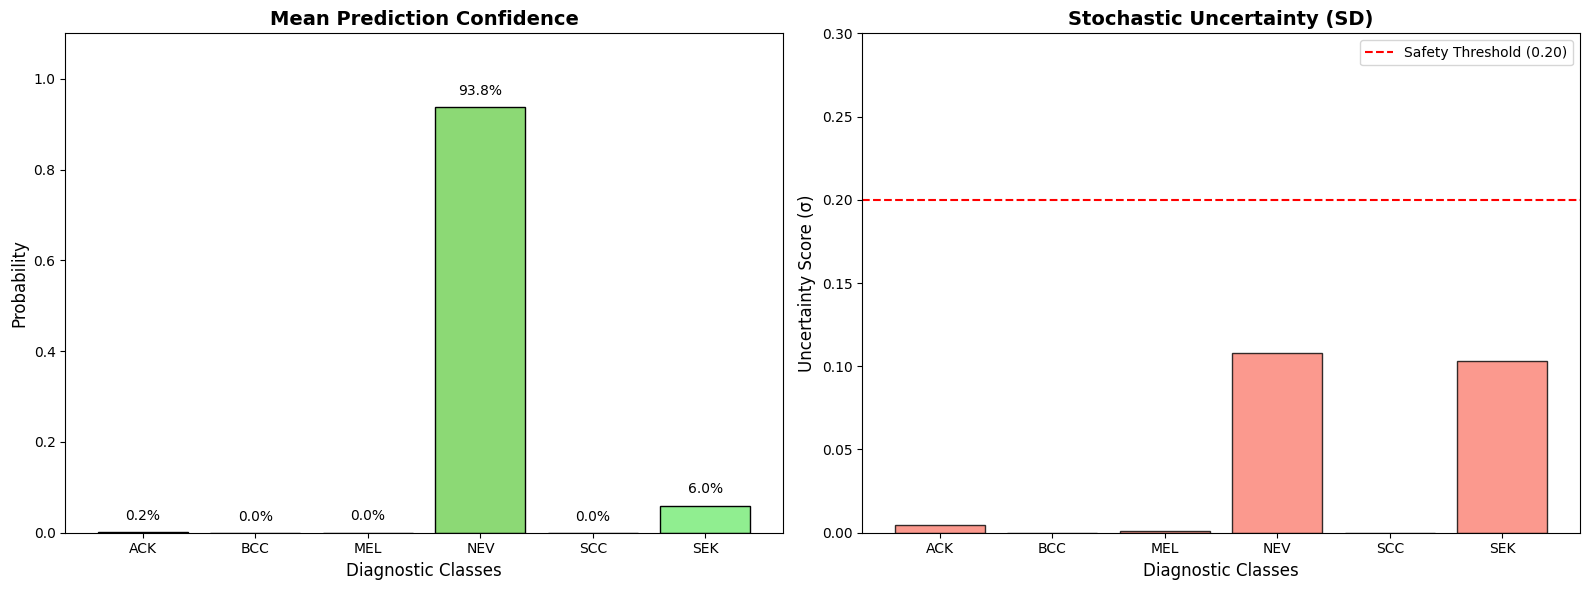

In [ ]:
idx = 33

# Extract specific validation image and paired metadata row
sample_img = X_val_img[idx]
sample_meta = X_val_meta[idx:idx+1]

# Run the fixed Monte Carlo analysis function
plot_mc_analysis(model, sample_img, sample_meta, le, iterations=50, threshold=0.20)

In [ ]:
import cv2
import numpy as np

def remove_hair(img):
    # Convert to grayscale
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Blackhat filtering to highlight hair (dark streaks on light background)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

  #binary mask technique
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Inpainting to fill the masked area with neighboring pixels
    dst = cv2.inpaint((img * 255).astype(np.uint8), mask, 1, cv2.INPAINT_TELEA)

    return dst / 255.0  # Return normalized


In [ ]:
import tensorflow as tf
import matplotlib.cm as cm

def get_integrated_gradcam(model, img_array, meta_array, last_conv_layer_name):
    # 1. Setup the Grad-Model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model([img_array, meta_array])
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Calculate Heatmap
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, title="Grad-CAM", alpha=0.4):
    # Resize and colorize
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap).resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose
    superimposed_img = jet_heatmap * alpha + img * 255
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return superimposed_img

/tmp/ipykernel_931/2526483068.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


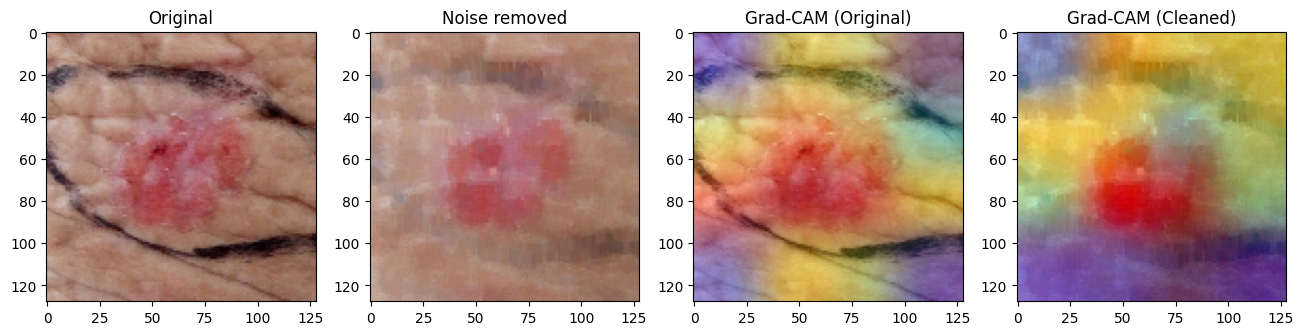

In [ ]:
# 1. Pick a sample
idx = 42
original_img = X_val_img[idx]
meta_data = X_val_meta[idx:idx+1]

# 2. Remove hair
cleaned_img = remove_hair(original_img)
cleaned_img_batch = np.expand_dims(cleaned_img, axis=0)

# 4. Generate heatmaps targeting MobileNetV2's final conv layer name ("out_relu")
heatmap_raw = get_multimodal_gradcam(model, base_model, original_img_batch, meta_data, "out_relu")
heatmap_clean = get_multimodal_gradcam(model, base_model, cleaned_img_batch, meta_data, "out_relu")

# 4. Visualize Results
res_raw = display_gradcam(original_img, heatmap_raw)
res_clean = display_gradcam(cleaned_img, heatmap_clean)

plt.figure(figsize=(16, 8))
plt.subplot(1, 4, 1); plt.imshow(original_img); plt.title("Original")
plt.subplot(1, 4, 2); plt.imshow(cleaned_img); plt.title("Noise removed")
plt.subplot(1, 4, 3); plt.imshow(res_raw); plt.title("Grad-CAM (Original)")
plt.subplot(1, 4, 4); plt.imshow(res_clean); plt.title("Grad-CAM (Cleaned)")
plt.show()

In [ ]:
# Save the final trained model configuration and weights
model.save('best_multimodal_mobilenet.keras')
print("Model saved successfully in Colab environment memory!")

Model saved successfully in Colab environment memory!


In [ ]:
from google.colab import files

# This will trigger the browser download prompt for the model
files.download('best_multimodal_mobilenet.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# Save the scaler object to a file named 'scaler.pkl'
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the label encoder object to a file named 'label_encoder.pkl'
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Files successfully serialized in Colab environment!")

Files successfully serialized in Colab environment!


In [ ]:
from google.colab import files

# Download the scaler
files.download('scaler.pkl')

# Download the label encoder
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
from google.colab import files

training_columns = X_meta_dummies.columns.tolist()
with open('meta_columns.pkl', 'wb') as f:
    pickle.dump(training_columns, f)

files.download('meta_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>